# MAD-CORE dataset summary

[MAD-CORE](https://archive.materialscloud.org) is an *ordered coreset* of
$2^{24}$ (≈16.8 M) structures picked by farthest-point sampling (FPS) from
MAD-COSMO, a pool of 1.7 billion structures collected from 656 public
atomistic datasets. Because the rows are stored in FPS order, the first
$2^k$ rows are themselves the level-$k$ coreset. Every energy and force in
the record is **predicted by the model used for the selection**
(`ecumetric_energy`, `ecumetric_nc_forces`): there are no DFT labels.

This notebook:

1. checks the files against `index.json`;
2. streams **all** $2^{24}$ frames once (in parallel, with a small
   extxyz parser checked against ASE) to summarise sources, composition,
   sizes, labels and the coreset diagnostics (`epsilon_sq`,
   `voronoi_population`, ZBL filters);
3. builds **metatomic** `System`s with `vesin.metatomic` neighbour lists for
   geometry checks, and stores the labels as **metatensor** `TensorMap`s with
   the layouts metatomic defines for `energy` and `non_conservative_force`;
4. checks the FPS ordering against the shipped selection features;
5. compares the labels with PET-MAD, run directly as a metatomic model;
6. writes a **chemiscope** view of the level-11 coreset (the first 2048
   structures), with described properties, force arrows and map settings.

Download (keep the `.gz` files, ASE and this notebook read them directly):

```bash
MC_TOKEN=<preview-token> bash ~/metawork/etc/download-madcore-extxyz.sh --keep-gz
```

plus `index.json`, `dataset_metadata.csv` and `madcore_features_0-2pow18.h5`
from the same record.

In [1]:
import gzip
import hashlib
import itertools
import json
import multiprocessing
import os
import pickle
import re
import warnings
from array import array
from pathlib import Path

warnings.filterwarnings("ignore", message=".*vesin.metatomic was only tested.*")
warnings.filterwarnings("ignore", message=".*non_conservative_forces' output name is deprecated.*")

import ase  # noqa: E402
import ase.io
import chemiscope
import h5py
import matplotlib.pyplot as plt
import metatensor.torch as mts
import metatomic.torch as mta
import numpy as np
import pandas as pd
import scipy.sparse
import torch
from ase.data import chemical_symbols
from IPython.display import display

try:
    from metatomic_ase import MetatomicCalculator
except ImportError:  # older metatomic ships it inside metatomic.torch
    from metatomic.torch.ase_calculator import MetatomicCalculator

import vesin.metatomic

DATA_DIR = Path(os.environ.get("MADCORE_DIR", "~/data/madcore")).expanduser()
OUT_DIR = Path(os.environ.get("MADCORE_OUT", "madcore-outputs"))
N_MAP = int(os.environ.get("MADCORE_N_MAP", 2**11))  # head of the FPS order shown in chemiscope
N_RANDOM = int(os.environ.get("MADCORE_N_RANDOM", 2**11))  # uniform sample over all rows
VERIFY_SHA = os.environ.get("MADCORE_VERIFY_SHA", "0") == "1"
PET_MAD = Path(
    os.environ.get("PET_MAD_MODEL", "~/metawork/openmm-metatomic/models/pet-mad-xs-v1.5.0.pt")
).expanduser()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 0
TOP = 20  # dataset groups shown individually in plots

OUT_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"data: {DATA_DIR}  device: {DEVICE}")

data: /home/boittier/data/madcore  device: cuda


## 1. Files

`index.json` lists every file with its size, SHA-256 and row range. Set
`MADCORE_VERIFY_SHA=1` to hash the local copies (about a minute for the
11 GB of structures).

In [2]:
index = json.loads((DATA_DIR / "index.json").read_text())


def sha256(path, chunk=2**24):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


files = pd.DataFrame(
    [
        {
            "file": name,
            "family": meta["family"],
            "rows": meta["rows"][1] - meta["rows"][0] if "rows" in meta else None,
            "first_row": meta["rows"][0] if "rows" in meta else None,
            "GB": meta["bytes"] / 1e9,
            "local": (DATA_DIR / name).exists(),
            "size_ok": (DATA_DIR / name).exists() and (DATA_DIR / name).stat().st_size == meta["bytes"],
            **({"sha_ok": sha256(DATA_DIR / name) == meta["sha256"]} if VERIFY_SHA and (DATA_DIR / name).exists() else {}),
        }
        for name, meta in index["files"].items()
    ]
).sort_values(["family", "first_row"])
display(files.style.format({"GB": "{:.3f}", "rows": "{:,.0f}", "first_row": "{:,.0f}"}, na_rep="").hide(axis="index"))

shards = files[(files.family == "xyz") & files.local].sort_values("first_row")
assert shards.size_ok.all(), "some shards are incomplete -- re-run the download"
n_rows = int(shards.rows.sum())
print(f"{len(shards)} structure shards present, {n_rows:,} rows ({n_rows / 2**24:.0%} of 2^24)")

file,family,rows,first_row,GB,local,size_ok
madcore_features_0-2pow18.h5,features,"262,144",0,0.455,True,True
madcore_features_2pow18-2pow19.h5,features,"262,144","262,144",0.455,False,False
madcore_features_2pow19-2pow20.h5,features,"524,288","524,288",0.909,False,False
madcore_features_2pow20-2pow21.h5,features,"1,048,576","1,048,576",1.816,False,False
madcore_features_2pow21-2pow22.h5,features,"2,097,152","2,097,152",3.625,False,False
madcore_features_2pow22-2pow23.h5,features,"4,194,304","4,194,304",7.239,False,False
madcore_features_2pow23-2pow24.h5,features,"8,388,608","8,388,608",14.460,False,False
LICENSES.md,global,,,0.000,True,True
README.md,global,,,0.000,True,True
dataset_metadata.csv,global,,,0.000,True,True


7 structure shards present, 16,777,216 rows (100% of 2^24)


## 2. Source datasets

`dataset_metadata.csv` describes the 656 source datasets (grouped into
`dataset_group`s), their licence, DOI, and how many structures they
contributed to the 1.7 B-structure MAD-COSMO pool.

In [3]:
sources = pd.read_csv(DATA_DIR / "dataset_metadata.csv")
licence = sources.license.str.upper().str.replace(r"[-.]?0$|\.0$", "", regex=True).str.replace("CC-BY-4", "CC-BY-4.0")
print(
    f"{len(sources)} datasets in {sources.dataset_group.nunique()} groups, "
    f"{sources.rows.sum():,} structures in MAD-COSMO"
)
display(pd.concat([sources.source_kind.value_counts().to_frame("datasets"), licence.value_counts().to_frame("datasets")], keys=["source kind", "licence"]))

656 datasets in 455 groups, 1,693,986,898 structures in MAD-COSMO


datasets
source kind colabfit                                                 398
            source_shard_and_entry                                   227
            source_token_or_hash                                      30
            mad_coreset                                                1
licence     CC-BY-4.0                                                532
            MIT                                                       55
            CC0-1                                                     23
            BSD-3-CLAUSE                                              14
            APACHE-2                                                  14
            NIST-PD                                                   11
            CC-BY-SA-4                                                 3
            CC-BY-3                                                    1
            CC                                                         1
            GDB TERMS OF USE (GDB.UNIBE.CH): CITATION REQUI...         1
            LICENSE ADDENDUM,CC-BY-4.0                                 1

## 3. One pass over every structure

ASE parses about 3k frames/s, which would take hours for $2^{24}$ frames.
The reader below parses the same extxyz at about 30k frames/s per process
and runs one process per shard. For every frame it keeps the header
metadata and a few derived scalars (so the statistics below cover the
*whole* coreset), the composition as a sparse row, and full `ase.Atoms`
for the rows we sample. It is checked against `ase.io.read` right after.

In [4]:
KV = re.compile(r'(\w+)=("[^"]*"|\S+)')
Z_OF = {s: z for z, s in enumerate(chemical_symbols)}
FLOAT_KEYS = ["ecumetric_energy", "epsilon_sq", "zbl_max_force", "zbl_energy_per_atom", "zbl_max_atomic_energy"]
INT_KEYS = ["fps_order", "k_set", "voronoi_population"]
CAT_KEYS = ["dataset_group", "dataset_id"]


def columns(properties):
    """Column slices of each per-atom array in an extxyz ``Properties`` string."""
    fields, start = {}, 0
    for name, _, n in zip(*[iter(properties.split(":"))] * 3):
        fields[name] = slice(start, start + int(n))
        start += int(n)
    return fields, start


def to_atoms(z, pos, forces, header):
    pbc = [p == "T" for p in header.get("pbc", '"F F F"').strip('"').split()]
    cell = np.array(header["Lattice"].strip('"').split(), float).reshape(3, 3) if "Lattice" in header else None
    atoms = ase.Atoms(numbers=z, positions=pos, cell=cell, pbc=pbc)
    atoms.arrays["ecumetric_nc_forces"] = forces
    for k in FLOAT_KEYS:
        atoms.info[k] = float(header[k])
    for k in INT_KEYS:
        atoms.info[k] = int(header[k])
    for k in [*CAT_KEYS, "configuration_id", "source_reference"]:
        atoms.info[k] = header[k].strip('"')
    return atoms


def scan_shard(task, limit=None):
    path, keep = task
    out = {k: array("d") for k in [*FLOAT_KEYS, "max_force", "rms_force", "volume", "min_cell_height"]}
    out |= {k: array("q") for k in [*INT_KEYS, "n_atoms", "n_species", "periodic"]}
    cats = {k: ({}, array("i")) for k in CAT_KEYS}
    comp_z, comp_n = array("B"), array("i")
    layouts, kept = {}, {}
    with gzip.open(path, "rt") as f:
        for row, line in enumerate(f):
            if row == limit:
                break
            n = int(line)
            header = dict(KV.findall(next(f)))
            if header["Properties"] not in layouts:
                layouts[header["Properties"]] = columns(header["Properties"])
            fields, width = layouts[header["Properties"]]
            table = np.array(" ".join(itertools.islice(f, n)).split()).reshape(n, width)
            z = np.fromiter((Z_OF[s] for s in table[:, fields["species"]].ravel()), np.int64, n)
            forces = table[:, fields["ecumetric_nc_forces"]].astype(float)
            fnorm = np.sqrt((forces**2).sum(1))
            uz, cnt = np.unique(z, return_counts=True)
            comp_z.extend(uz.astype(np.uint8)), comp_n.extend(cnt)
            pbc = header.get("pbc", '"F F F"').strip('"').split() == ["T", "T", "T"]
            if pbc:
                cell = np.array(header["Lattice"].strip('"').split(), float).reshape(3, 3)
                volume = abs(np.linalg.det(cell))
                heights = volume / np.linalg.norm(np.cross(cell[[1, 2, 0]], cell[[2, 0, 1]]), axis=1)
            for k in FLOAT_KEYS:
                out[k].append(float(header[k]))
            for k in INT_KEYS:
                out[k].append(int(header[k]))
            for k, (codes, values) in cats.items():
                values.append(codes.setdefault(header[k].strip('"'), len(codes)))
            out["n_atoms"].append(n), out["n_species"].append(len(uz)), out["periodic"].append(pbc)
            out["max_force"].append(fnorm.max()), out["rms_force"].append(np.sqrt((fnorm**2).mean()))
            out["volume"].append(volume if pbc else np.nan)
            out["min_cell_height"].append(heights.min() if pbc else np.nan)
            if row in keep:
                kept[row] = to_atoms(z, table[:, fields["pos"]].astype(float), forces, header)
    frame = pd.DataFrame({k: np.frombuffer(v, dtype=v.typecode) for k, v in out.items()})
    for k, (codes, values) in cats.items():
        frame[k] = pd.Categorical.from_codes(np.frombuffer(values, np.int32), list(codes))
    frame["periodic"] = frame.periodic.astype(bool)
    return frame, (np.frombuffer(comp_z, np.uint8), np.frombuffer(comp_n, np.int32)), kept, list(layouts)

In [5]:
# the fast reader must agree with ASE, on the head of the first shard and on
# frames from the largest shard (periodic and not)
def check_reader(path, n=300):
    reference = ase.io.read(path, index=f":{n}", format="extxyz")
    kept = scan_shard((path, set(range(n))), limit=n)[2]
    for i, ref in enumerate(reference):
        mine = kept[i]
        assert (mine.numbers == ref.numbers).all() and np.allclose(mine.positions, ref.positions)
        assert np.allclose(mine.arrays["ecumetric_nc_forces"], ref.arrays["ecumetric_nc_forces"])
        assert (mine.pbc == ref.pbc).all() and np.allclose(mine.cell.array, ref.cell.array)
        assert np.isclose(mine.info["ecumetric_energy"], ref.info["ecumetric_energy"])
    return sum(a.pbc.all() for a in reference)


for p in [shards.file.iloc[0], shards.file.iloc[-1]]:
    print(f"reader matches ASE on {p} ({check_reader(DATA_DIR / p)} periodic frames checked)")

reader matches ASE on madcore_0-2pow18.extxyz.gz (291 periodic frames checked)


reader matches ASE on madcore_2pow23-2pow24.extxyz.gz (299 periodic frames checked)


In [6]:
rng = np.random.default_rng(SEED)
random_rows = np.sort(rng.choice(n_rows, size=N_RANDOM, replace=False))
tasks = [
    (
        DATA_DIR / r.file,
        {i - r.first_row for i in random_rows if r.first_row <= i < r.first_row + r.rows}
        | (set(range(N_MAP)) if r.first_row == 0 else set()),
    )
    for r in shards.itertuples()
]
cache = DATA_DIR / f".summary-cache-{n_rows}-{N_MAP}-{N_RANDOM}-{SEED}.pkl"
if cache.exists():
    df, comp, kept, layouts = pickle.loads(cache.read_bytes())
else:
    with multiprocessing.get_context("fork").Pool(len(tasks)) as pool:
        parts = pool.map(scan_shard, tasks)
    df = pd.concat([p[0] for p in parts], ignore_index=True)
    for k in CAT_KEYS:  # categories differ per shard; unify them
        df[k] = df[k].astype(str).astype("category")
    comp = tuple(np.concatenate([p[1][i] for p in parts]) for i in range(2))
    kept = {first + row: atoms for (_, _, k, _), first in zip(parts, shards.first_row) for row, atoms in k.items()}
    layouts = sorted({layout for p in parts for layout in p[3]})
    cache.write_bytes(pickle.dumps((df, comp, kept, layouts)))

assert (df.fps_order.to_numpy() == np.arange(n_rows)).all(), "rows are not in fps order"
X = scipy.sparse.csr_matrix(
    (comp[1], comp[0], np.concatenate([[0], np.cumsum(df.n_species.to_numpy())])), shape=(n_rows, 119)
)  # composition: X[i, Z] = number of atoms of element Z in structure i
head = [kept[i] for i in range(N_MAP)]
random_sample = [kept[i] for i in random_rows]
print(f"{n_rows:,} structures, {df.n_atoms.sum():,} atoms; per-atom layouts: {layouts}")

16,777,216 structures, 216,185,078 atoms; per-atom layouts: ['species:S:1:pos:R:3:ecumetric_nc_forces:R:3']


## 4. Composition and size

In [7]:
presence = np.asarray((X > 0).sum(0)).ravel()
atoms_per_z = np.asarray(X.sum(0)).ravel()
present = np.flatnonzero(presence)
elements = [chemical_symbols[z] for z in present]
print(f"{len(elements)} elements: {' '.join(elements)}")

top_groups = df.dataset_group.value_counts().index[:TOP]
df["group"] = df.dataset_group.astype(str).where(df.dataset_group.isin(top_groups), "other").astype("category")
GROUP_ORDER = [*top_groups, "other"]
COLOR = dict(zip(GROUP_ORDER, [*plt.cm.tab20.colors, (0.6, 0.6, 0.6)]))

overview = df.groupby("dataset_group", observed=True).agg(
    structures=("fps_order", "size"),
    atoms=("n_atoms", "sum"),
    median_atoms=("n_atoms", "median"),
    periodic=("periodic", "mean"),
    first_pick=("fps_order", "min"),
)
cosmo = sources.groupby("dataset_group").rows.sum()
known = set(sources.dataset_id) | set(sources.colabfit_ds_id.dropna())  # ColabFit rows use their DS_ ids
missing = sorted(set(df.dataset_id.cat.categories) - known)
print(f"{df.dataset_id.nunique()} dataset_ids in the structures, {len(missing)} without an entry in dataset_metadata.csv", missing[:10])
overview["share_of_coreset"] = overview.structures / n_rows
overview["share_of_MAD_COSMO"] = cosmo.reindex(overview.index) / cosmo.sum()
overview["enrichment"] = overview.share_of_coreset / overview.share_of_MAD_COSMO
short = lambda name: name if len(name) <= 30 else name[:28] + "…"  # noqa: E731
display(
    overview.sort_values("structures", ascending=False)
    .head(30)
    .drop(columns="atoms")
    .rename(index=short, columns={"median_atoms": "atoms (med.)", "first_pick": "first pick", "share_of_coreset": "coreset", "share_of_MAD_COSMO": "MAD-COSMO", "enrichment": "enrich."})
    .style.format({"structures": "{:,}", "periodic": "{:.0%}", "coreset": "{:.2%}", "MAD-COSMO": "{:.2%}", "enrich.": "{:.1f}", "atoms (med.)": "{:.0f}"})
)

102 elements: H He Li Be B C N O F Ne Na Mg Al Si P S Cl Ar K Ca Sc Ti V Cr Mn Fe Co Ni Cu Zn Ga Ge As Se Br Kr Rb Sr Y Zr Nb Mo Tc Ru Rh Pd Ag Cd In Sn Sb Te I Xe Cs Ba La Ce Pr Nd Pm Sm Eu Gd Tb Dy Ho Er Tm Yb Lu Hf Ta W Re Os Ir Pt Au Hg Tl Pb Bi Po At Rn Fr Ra Ac Th Pa U Np Pu Am Cm Bk Cf Es Fm Md No


666 dataset_ids in the structures, 3 without an entry in dataset_metadata.csv ['MAD-1.5', 'mad_next', 'mad_sol']


,structures,atoms (med.),periodic,first pick,coreset,MAD-COSMO,enrich.
dataset_group,,,,,,,
OMat24,"9,452,931",12,100%,1,56.34%,6.25%,9.0
Alexandria,"3,159,704",6,100%,3,18.83%,6.98%,2.7
JARVIS_QE_TB,"590,179",3,100%,2,3.52%,0.05%,71.8
MP-ALOE,"571,477",6,100%,1841,3.41%,0.05%,63.4
JARVIS_OQMD_no_CFID,"382,134",4,100%,458,2.28%,0.05%,47.5
nomad,"379,008",5,99%,31,2.26%,0.32%,7.1
OMol25,"367,234",10,0%,2029,2.19%,8.39%,0.3
mad-next,"340,555",3,57%,0,2.03%,0.02%,101.0
JARVIS_CFID_OQMD,"299,175",4,100%,170,1.78%,0.03%,65.7


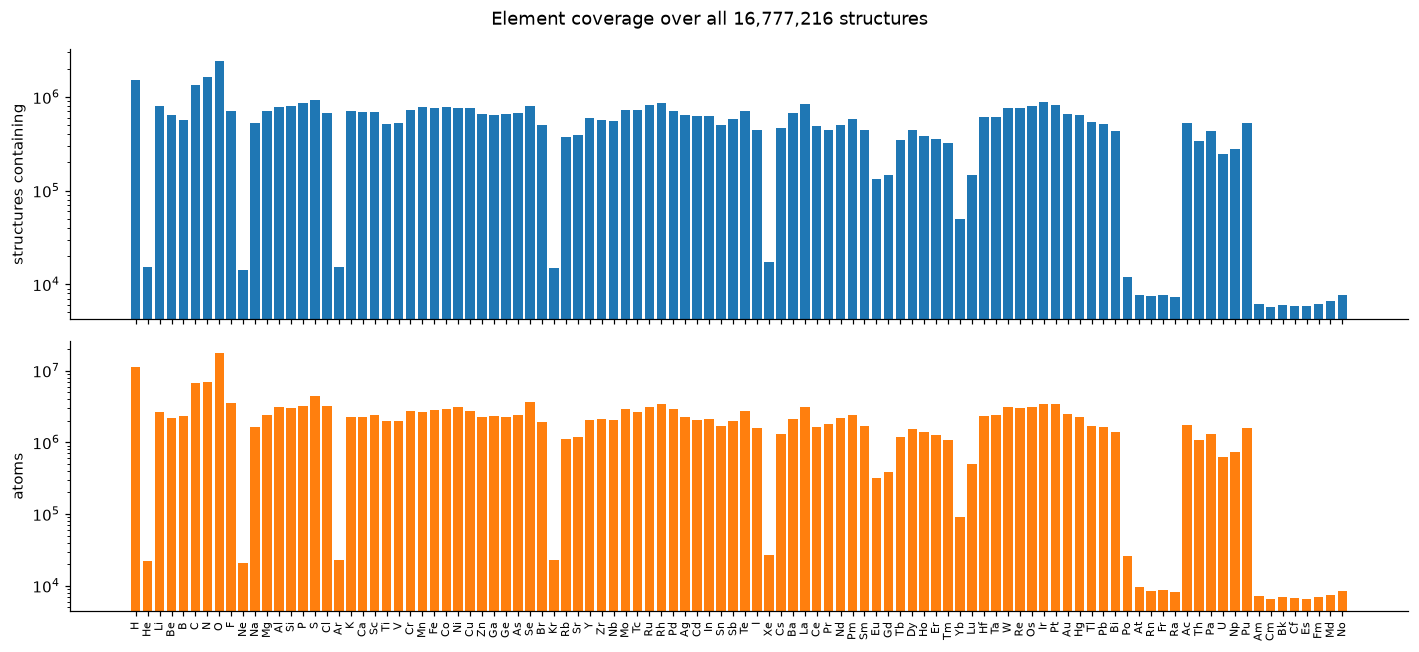

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
z = np.arange(1, present.max() + 1)
ax[0].bar(z, presence[z], color="C0")
ax[0].set(ylabel="structures containing", yscale="log")
ax[1].bar(z, atoms_per_z[z], color="C1")
ax[1].set(ylabel="atoms", yscale="log")
ax[1].set_xticks(z, [chemical_symbols[i] for i in z], rotation=90, fontsize=7)
fig.suptitle(f"Element coverage over all {n_rows:,} structures")
fig.tight_layout()

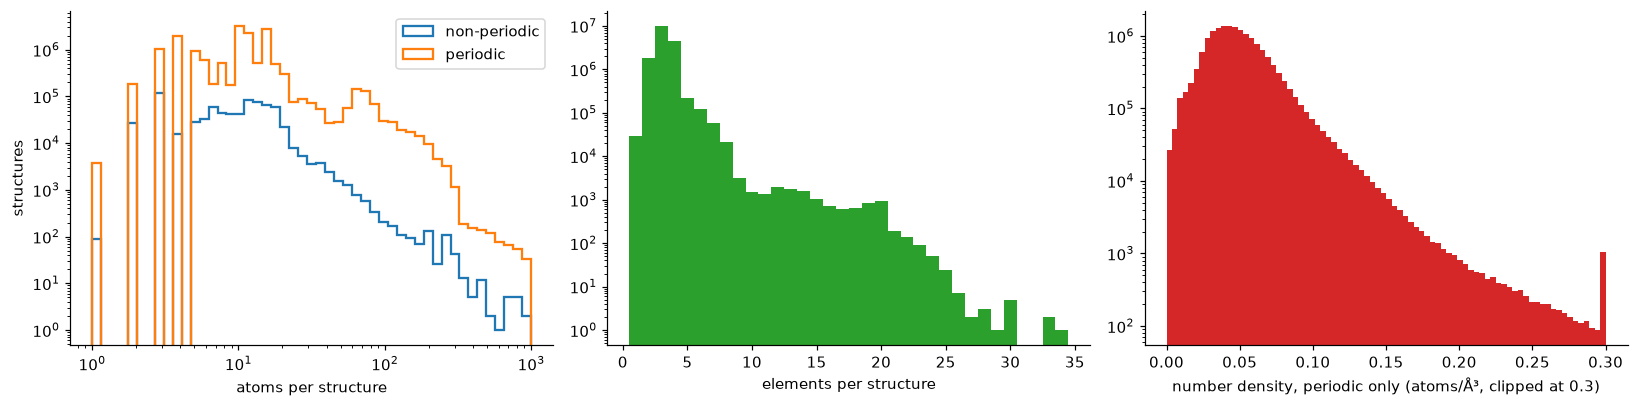

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
bins = np.logspace(0, np.log10(df.n_atoms.max() + 1), 50)
for periodic, g in df.groupby("periodic"):
    ax[0].hist(g.n_atoms, bins=bins, histtype="step", lw=1.5, label="periodic" if periodic else "non-periodic")
ax[0].set(xscale="log", yscale="log", xlabel="atoms per structure", ylabel="structures")
ax[0].legend()
ax[1].hist(df.n_species, bins=np.arange(0.5, df.n_species.max() + 1.5), color="C2")
ax[1].set(xlabel="elements per structure", yscale="log")
density = (df.n_atoms / df.volume).dropna()
ax[2].hist(density.clip(upper=0.3), bins=80, color="C3")
ax[2].set(xlabel="number density, periodic only (atoms/Å³, clipped at 0.3)", yscale="log")
fig.tight_layout()

## 5. The coreset ordering

`k_set` is the level at which a row entered: level $k$ holds rows
$2^{k-1}\ldots 2^k-1$, so the level-$k$ coreset is the first $2^k$ rows.
`epsilon_sq` is the (squared, in scaled feature space) Hausdorff distance
of the coreset to the whole pool, i.e. its resolution. Up to level 19 it is
a single value per level (the levels were picked as blocks); from level 20
on it decreases pick by pick, so the value at the end of level $k$ (its
minimum) is the resolution of the first $2^k$ rows. Section 9 checks the
per-level values against the features.
`voronoi_population` is the number of MAD-COSMO structures closest to each
pick, i.e. the weight a pick carries. The last panel shows how the mix of
sources changes between levels.

epsilon_sq monotone non-increasing: True
k_set == ceil(log2(fps_order + 1)) except row 0: True | row 0 has k_set 1


levels with a single epsilon_sq: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
voronoi populations sum to 1,694,502,355 (MAD-COSMO has 1,693,986,898)


,rows,epsilon_sq,distinct_epsilon,voronoi_population
k_set,,,,
1,2,578.3,1,"77,269"
2,2,335.4,1,"2,625"
3,4,157.1,1,871
4,8,85.54,1,"1,163"
5,16,49.18,1,"6,072"
6,32,30.4,1,"6,156"
7,64,21.3,1,"1,455"
8,128,14.72,1,"6,060"
9,256,10.42,1,"4,760"


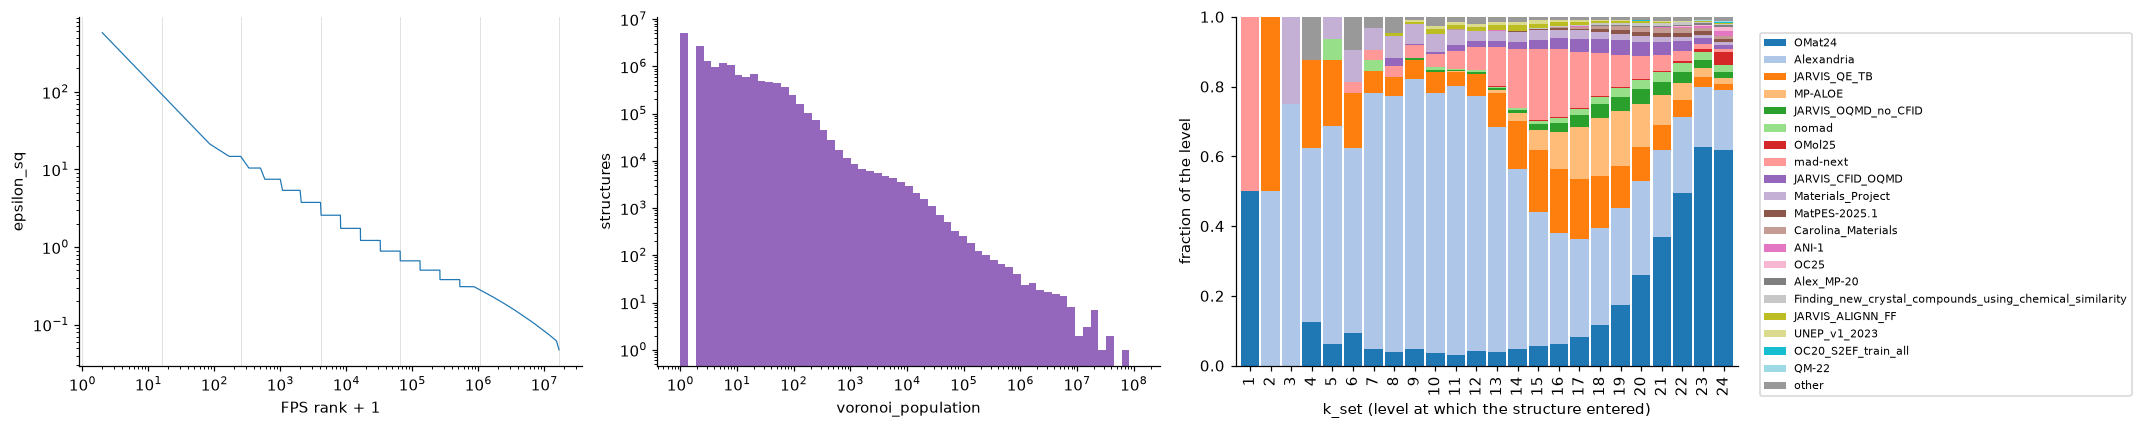

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
stride = max(1, n_rows // 200_000)
ax[0].loglog(df.fps_order[1::stride] + 1, df.epsilon_sq[1::stride], lw=0.8)
ax[0].set(xlabel="FPS rank + 1", ylabel="epsilon_sq")
for k in range(0, 25, 4):
    ax[0].axvline(2**k, color="0.85", lw=0.5, zorder=-1)
pop = df.voronoi_population
ax[1].hist(pop[pop > 0], bins=np.logspace(0, np.log10(pop.max()), 60), color="C4")
ax[1].set(xscale="log", yscale="log", xlabel="voronoi_population", ylabel="structures")
level = pd.crosstab(df.k_set, df.group, normalize="index")[GROUP_ORDER]
level.plot.bar(stacked=True, ax=ax[2], color=[COLOR[g] for g in GROUP_ORDER], width=0.9, legend=False)
ax[2].set(xlabel="k_set (level at which the structure entered)", ylabel="fraction of the level")
fig.legend(*ax[2].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7)
fig.tight_layout()

print("epsilon_sq monotone non-increasing:", bool((np.diff(df.epsilon_sq.to_numpy()[1:]) <= 1e-6 * df.epsilon_sq.max()).all()))
bit_length = np.ceil(np.log2(df.fps_order + 1)).astype(int)
print("k_set == ceil(log2(fps_order + 1)) except row 0:", bool((df.k_set == bit_length)[1:].all()), "| row 0 has k_set", df.k_set.iloc[0])
per_level = df.groupby("k_set").epsilon_sq.nunique()
print("levels with a single epsilon_sq:", per_level.index[per_level == 1].tolist())
print(f"voronoi populations sum to {pop.sum():,} (MAD-COSMO has {sources.rows.sum():,})")
levels = df.groupby("k_set").agg(
    rows=("fps_order", "size"),
    epsilon_sq=("epsilon_sq", "min"),
    distinct_epsilon=("epsilon_sq", "nunique"),
    voronoi_population=("voronoi_population", "sum"),
)
display(levels.style.format({"epsilon_sq": "{:.4g}", "rows": "{:,}", "distinct_epsilon": "{:,}", "voronoi_population": "{:,}"}))

## 6. Labels

Energies from different sources are on different references (and every
label here comes from the same model anyway), so we fit a per-element
linear baseline $E \approx \sum_Z n_Z\,\mu_Z$ over all structures (the
composition model metatrain fits before training) and look at the
residual per atom. The ZBL diagnostics were used to filter unphysical
close contacts when the coreset was built.

In [11]:
E = df.ecumetric_energy.to_numpy()
Xp = X[:, present].astype(float)
mu = np.linalg.lstsq((Xp.T @ Xp).toarray(), Xp.T @ E, rcond=None)[0]  # exact least squares via normal equations
df["energy_per_atom"] = E / df.n_atoms
df["residual_per_atom"] = (E - Xp @ mu) / df.n_atoms
grid = [f"{e}: {m:.2f}" for e, m in zip(elements, mu)]
grid += [""] * (-len(grid) % 12)
display(pd.DataFrame(np.reshape(grid, (-1, 12))).style.hide(axis="index").hide(axis="columns").set_caption("per-element energies μ (eV)"))
print(f"composition baseline residual: median |r| {df.residual_per_atom.abs().median():.3f}, MAE {df.residual_per_atom.abs().mean():.3f}, "
      f"RMSE {np.sqrt((df.residual_per_atom**2).mean()):.3f} eV/atom -- a coreset keeps the far tails, hence mean >> median")

stats = df.groupby("group", observed=True)[["energy_per_atom", "residual_per_atom", "max_force", "rms_force"]].median()
stats["structures"] = df.group.value_counts()
stats.columns = ["E/atom (eV)", "residual (eV)", "max |F| (eV/Å)", "rms |F| (eV/Å)", "structures"]
display(stats.loc[GROUP_ORDER].rename(index=short).style.format({**{c: "{:.3g}" for c in stats.columns[:4]}, "structures": "{:,}"}).set_caption("medians per group"))

H: -3.96,He: 0.75,Li: -2.15,Be: -3.01,B: -5.95,C: -8.44,N: -8.36,O: -7.91,F: -5.06,Ne: 0.12,Na: -1.26,Mg: -1.26
Al: -3.85,Si: -5.71,P: -5.81,S: -5.16,Cl: -3.06,Ar: 0.34,K: -0.12,Ca: -2.29,Sc: -5.38,Ti: -7.23,V: -8.43,Cr: -8.39
Mn: -8.17,Fe: -6.62,Co: -6.73,Ni: -5.46,Cu: -3.31,Zn: -1.09,Ga: -3.24,Ge: -4.65,As: -4.97,Se: -4.40,Br: -2.09,Kr: 2.09
Rb: -0.45,Sr: -2.39,Y: -5.57,Zr: -7.79,Nb: -9.69,Mo: -9.84,Tc: -9.34,Ru: -8.22,Rh: -6.29,Pd: -3.74,Ag: -1.93,Cd: -0.21
In: -2.36,Sn: -3.90,Sb: -4.02,Te: -3.35,I: -1.22,Xe: 1.95,Cs: -0.47,Ba: -1.97,La: -5.47,Ce: -6.43,Pr: -5.65,Nd: -5.20
Pm: -4.57,Sm: -3.97,Eu: -4.14,Gd: -4.27,Tb: -3.07,Dy: -1.64,Ho: -2.56,Er: -2.35,Tm: -2.17,Yb: -1.72,Lu: -5.21,Hf: -7.80
Ta: -9.45,W: -9.57,Re: -9.85,Os: -9.51,Ir: -8.55,Pt: -6.07,Au: -2.93,Hg: 0.44,Tl: -1.80,Pb: -2.96,Bi: -3.52,Po: -2.61
At: 0.28,Rn: 6.10,Fr: 3.82,Ra: 3.46,Ac: -4.31,Th: -7.66,Pa: -9.16,U: -9.82,Np: -9.09,Pu: -7.21,Am: -1.43,Cm: -0.24
Bk: 0.72,Cf: 1.42,Es: 2.12,Fm: 2.71,Md: 2.78,No: 3.27,,,,,,


composition baseline residual: median |r| 0.565, MAE 0.740, RMSE 1.122 eV/atom -- a coreset keeps the far tails, hence mean >> median


,E/atom (eV),residual (eV),max |F| (eV/Å),rms |F| (eV/Å),structures
group,,,,,
OMat24,-5.08,0.389,8.61,4.43,"9,452,931"
Alexandria,-4.84,-0.383,0.409,0.273,"3,159,704"
JARVIS_QE_TB,-4.13,0.429,4.12e-06,3.06e-06,"590,179"
MP-ALOE,-5.69,0.327,1.44,1.01,"571,477"
JARVIS_OQMD_no_CFID,-5.5,-0.347,1.17e-06,7.77e-07,"382,134"
nomad,-4.99,-0.0463,8.4e-05,5.53e-05,"379,008"
OMol25,-5.18,0.666,6.15,3.35,"367,234"
mad-next,-2.69,0.829,1.91,1.41,"340,555"
JARVIS_CFID_OQMD,-4.81,0.0451,1.36e-05,9.18e-06,"299,175"


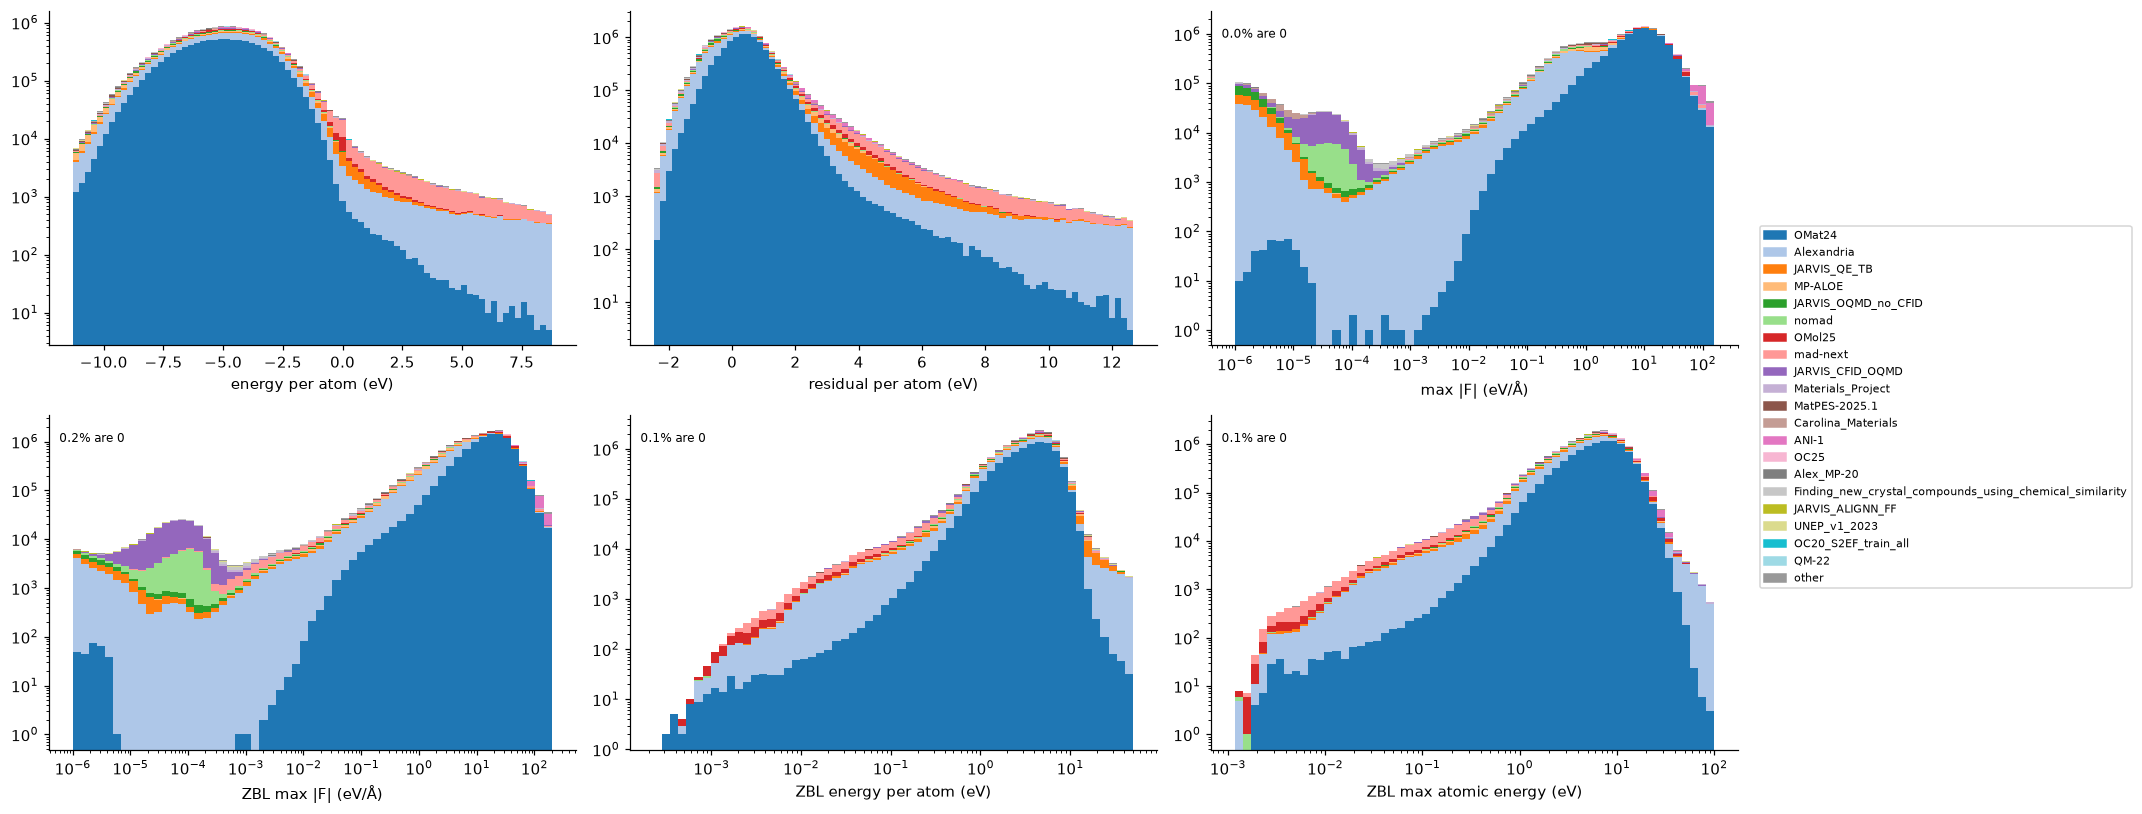

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(16, 7.5))
panels = [
    ("energy_per_atom", "energy per atom (eV)", False),
    ("residual_per_atom", "residual per atom (eV)", False),
    ("max_force", "max |F| (eV/Å)", True),
    ("zbl_max_force", "ZBL max |F| (eV/Å)", True),
    ("zbl_energy_per_atom", "ZBL energy per atom (eV)", True),
    ("zbl_max_atomic_energy", "ZBL max atomic energy (eV)", True),
]
for a, (col, label, log) in zip(ax.ravel(), panels):
    v = df[col]
    if log:
        lo = max(v[v > 0].min(), 1e-6) if (v > 0).any() else 1e-6
        bins = np.logspace(np.log10(lo), np.log10(max(v.max(), lo * 10)), 60)
        a.set_xscale("log")
        a.text(0.02, 0.92, f"{(v <= 0).mean():.1%} are 0", transform=a.transAxes, fontsize=8)
    else:
        bins = np.linspace(*np.percentile(v, [0.05, 99.95]), 80)
    a.hist([df.loc[df.group == g, col] for g in GROUP_ORDER], bins=bins, stacked=True, color=[COLOR[g] for g in GROUP_ORDER])
    a.set(xlabel=label, yscale="log")
fig.legend([plt.Rectangle((0, 0), 1, 1, color=COLOR[g]) for g in GROUP_ORDER], GROUP_ORDER, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7)
fig.tight_layout()

### Outliers

Structures whose residual is more than 8 robust standard deviations from
their group's median, or whose largest force exceeds 100 eV/Å. In a
coreset these are expected to be over-represented (FPS favours the edges
of the distribution), so treat the list as "worth a look", not "wrong".

In [13]:
g = df.groupby("dataset_group", observed=True).residual_per_atom
centre = g.transform("median")
spread = g.transform(lambda r: 1.4826 * (r - r.median()).abs().median()).replace(0, np.nan)
df["outlier"] = ((df.residual_per_atom - centre).abs() > 8 * spread).fillna(False) | (df.max_force > 100)
print(f"{df.outlier.sum():,} flagged structures ({df.outlier.mean():.3%})")
display(
    df.loc[df.outlier].groupby("dataset_group", observed=True).size().sort_values(ascending=False).head(15).rename(index=short).to_frame("flagged")
)
display(df.loc[df.outlier].nlargest(10, "max_force")[["fps_order", "dataset_group", "n_atoms", "energy_per_atom", "residual_per_atom", "max_force"]])

113,006 flagged structures (0.674%)


,flagged
dataset_group,
ANI-1,53299
OMat24,25463
Alexandria,23385
OC20-IS2RES,2004
Materials_Project,1244
OC22-IS2RE,1199
JARVIS_CFID_OQMD,1024
QM-22,898
UNEP_v1_2023,719


,fps_order,dataset_group,n_atoms,energy_per_atom,residual_per_atom,max_force
2770328,2770328,OMat24,30,-5.088625,2.007295,156.911960
2907189,2907189,OC22-IS2RE,87,-6.629766,0.326835,156.447582
11108067,11108067,OMat24,60,-4.072766,2.388131,155.912156
9121155,9121155,OC22-S2EF,113,-5.385176,1.787451,155.772102
2051178,2051178,OC22-S2EF,90,-6.501505,0.546363,155.529303
7776390,7776390,Materials_Project,49,-1.851767,4.836095,155.404880
3890217,3890217,OMat24,46,-3.564151,2.112773,155.372564
5017272,5017272,OMat24,64,-5.037971,1.862267,155.147084
13694454,13694454,OMat24,84,-3.938613,1.909574,155.071160
3505901,3505901,OMat24,98,-3.547657,2.825442,155.064981


## 7. metatomic systems and neighbour lists

The head of the coreset and the random sample are converted to metatomic
`System`s (float64, Å) and given a half neighbour list from
`vesin.metatomic`, exactly as an engine would before calling a model. The
shortest pair distance flags overlapping atoms; the minimum cell height
over the whole dataset tells us whether small periodic cells need a
neighbour list with multiple images (vesin handles that).

System with 1 atoms, non periodic
TensorBlock
    samples (0): ['first_atom', 'second_atom', 'cell_shift_a', 'cell_shift_b', 'cell_shift_c']
    components (3): ['xyz']
    properties (1): ['distance']
    gradients: None



99.7% of periodic cells are thinner than 2 x cutoff


,fps_order,dataset_group,n_atoms,min_distance,max_force
609,609,Alexandria,12,0.236431,58.791814
1109,1109,Alexandria,14,0.334289,105.230728
61,61,Alexandria,14,0.334423,92.762416
611,611,Alexandria,10,0.351055,70.224712
1123,1123,Alexandria,10,0.372303,62.757756
122,122,Alexandria,9,0.380852,92.197625
348,348,OMat24,5,0.396356,66.883072
8,8,OMat24,9,0.400026,42.959023


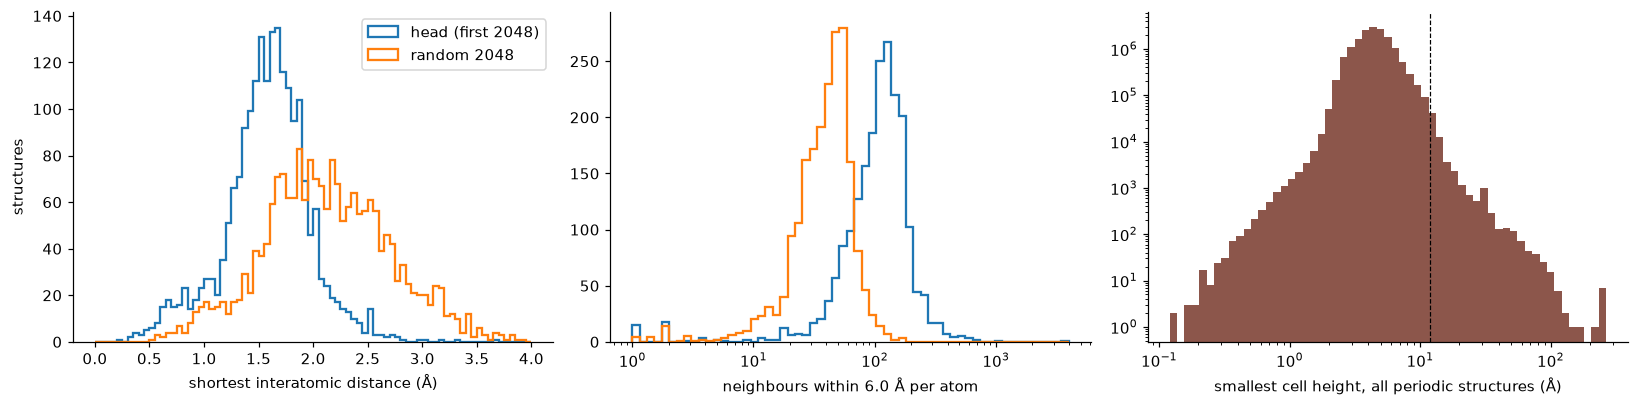

In [14]:
NL_OPTIONS = mta.NeighborListOptions(cutoff=6.0, full_list=False, strict=True)
nl_calc = vesin.metatomic.NeighborList(NL_OPTIONS, length_unit="angstrom")


def to_systems(frames):
    systems = mta.systems_to_torch(frames, dtype=torch.float64)
    for s in systems:
        s.add_neighbor_list(NL_OPTIONS, nl_calc.compute(s))
    return systems


def geometry(systems):
    d = [s.get_neighbor_list(NL_OPTIONS).values.reshape(-1, 3).norm(dim=1) for s in systems]
    return pd.DataFrame(
        {
            "min_distance": [x.min().item() if len(x) else np.nan for x in d],
            "neighbors_per_atom": [2 * len(x) / len(s) for x, s in zip(d, systems)],
        }
    )


with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # cells with pbc=False along an axis are zeroed, as intended
    head_systems, random_systems = to_systems(head), to_systems(random_sample)
print(head_systems[0])
print(head_systems[0].get_neighbor_list(NL_OPTIONS))

head_df = df.iloc[:N_MAP].reset_index(drop=True).join(geometry(head_systems))
random_df = df.iloc[random_rows].reset_index(drop=True).join(geometry(random_systems))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for name, d in [(f"head (first {N_MAP})", head_df), (f"random {N_RANDOM}", random_df)]:
    ax[0].hist(d.min_distance.dropna(), bins=np.linspace(0, 4, 81), histtype="step", lw=1.5, label=name)
    ax[1].hist(d.neighbors_per_atom, bins=np.logspace(0, np.log10(4000), 60), histtype="step", lw=1.5, label=name)
ax[0].set(xlabel="shortest interatomic distance (Å)", ylabel="structures")
ax[1].set(xscale="log", xlabel=f"neighbours within {NL_OPTIONS.cutoff} Å per atom")
ax[0].legend()
ax[2].hist(df.min_cell_height.dropna(), bins=np.logspace(np.log10(df.min_cell_height.min()), np.log10(df.min_cell_height.max()), 60), color="C5")
ax[2].axvline(2 * NL_OPTIONS.cutoff, color="k", ls="--", lw=0.8)
ax[2].set(xscale="log", yscale="log", xlabel="smallest cell height, all periodic structures (Å)")
fig.tight_layout()
print(f"{(df.min_cell_height < 2 * NL_OPTIONS.cutoff).mean() / df.periodic.mean():.1%} of periodic cells are thinner than 2 x cutoff")
display(pd.concat([head_df, random_df]).nsmallest(8, "min_distance")[["fps_order", "dataset_group", "n_atoms", "min_distance", "max_force"]])

## 8. Labels as metatensor `TensorMap`s

The labels are stored with the metadata metatomic prescribes for the
[`energy`](https://docs.metatensor.org/metatomic/latest/outputs/energy.html)
and
[`non_conservative_force`](https://docs.metatensor.org/metatomic/latest/outputs/non_conservative.html)
outputs. The forces here are *direct* (non-conservative) predictions, so
they belong in their own per-atom TensorMap, **not** in the `positions`
gradient of the energy. Keeping the sample `system` equal to `fps_order`
makes any slice of the coreset self-describing.

In [15]:
def label_tensormaps(frames):
    order = torch.tensor([a.info["fps_order"] for a in frames])
    energy = mts.TensorMap(
        mts.Labels.single(),
        [
            mts.TensorBlock(
                values=torch.tensor([a.info["ecumetric_energy"] for a in frames], dtype=torch.float64).reshape(-1, 1),
                samples=mts.Labels("system", order.reshape(-1, 1)),
                components=[],
                properties=mts.Labels("energy", torch.tensor([[0]])),
            )
        ],
    )
    atoms = torch.tensor([(o, j) for o, a in zip(order.tolist(), frames) for j in range(len(a))])
    force = mts.TensorMap(
        mts.Labels.single(),
        [
            mts.TensorBlock(
                values=torch.tensor(np.concatenate([a.arrays["ecumetric_nc_forces"] for a in frames])).reshape(-1, 3, 1),
                samples=mts.Labels(["system", "atom"], atoms),
                components=[mts.Labels("xyz", torch.arange(3).reshape(-1, 1))],
                properties=mts.Labels("non_conservative_force", torch.tensor([[0]])),
            )
        ],
    )
    return energy, force


energy_tm, force_tm = label_tensormaps(head)
print(energy_tm.block())
print(force_tm.block())
for name, tm in [("energy", energy_tm), ("non_conservative_force", force_tm)]:
    path = OUT_DIR / f"madcore-head-{name}.mts"
    mts.save(path, tm)
    assert mts.equal(mts.load(path), tm)

# net force per structure: direct predictions are not guaranteed to sum to zero
net = mts.sum_over_samples(force_tm, "atom").block().values.norm(dim=1).squeeze()
print(f"|sum of forces| over the head: median {net.median():.2e}, max {net.max():.2e} eV/Å")

TensorBlock
    samples (2048): ['system']
    components (): []
    properties (1): ['energy']
    gradients: None

TensorBlock
    samples (16826): ['system', 'atom']
    components (3): ['xyz']
    properties (1): ['non_conservative_force']
    gradients: None

|sum of forces| over the head: median 6.76e-02, max 1.03e+02 eV/Å


## 9. The coreset in feature space

`madcore_features_0-2pow18.h5` holds the 512-dimensional features used for
the selection. The head's scaled features are stored as a metatensor
TensorMap and projected with PCA for the map. We then check the recorded
resolution: since the first $2^{18}$ rows are a subset of the pool, the
largest squared distance from any of them to the level-$k$ coreset must not
exceed `epsilon_sq[k]`, and for a good coreset it should come close. The
last line tests whether the order is also *greedy* point by point (each
pick being the farthest point from all earlier ones).

{'features': (262144, 512), 'mean': (512,), 'scale': ()}


,epsilon_sq,max d² of later rows,d² of next pick,covered,greedy
k,,,,,
1,578.3,532.7,532.7,True,True
2,335.4,213.6,213.6,True,True
3,157.1,149.6,149.6,True,True
4,85.54,84.38,84.38,True,True
5,49.18,48.44,31.2,True,False
6,30.4,30.34,25.26,True,False
7,21.3,21.28,17.6,True,False
8,14.72,14.69,13.59,True,False
9,10.42,10.42,9.579,True,False


every later row inside epsilon_sq of each level: True; greedy at 6/14 levels
PCA explained variance: [0.312 0.174 0.095]


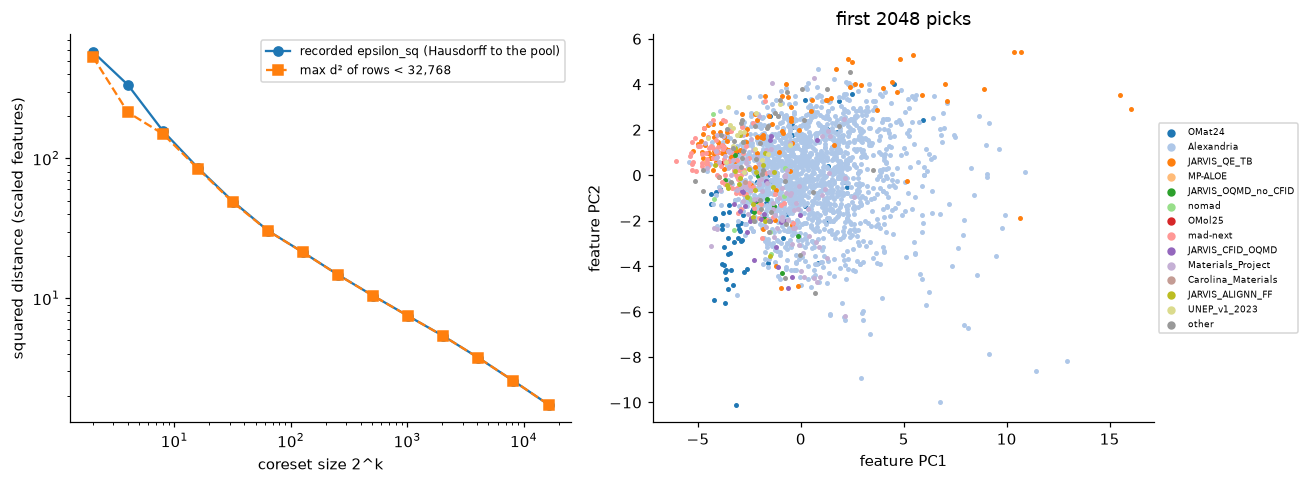

In [16]:
N_CHECK = min(2**15, n_rows)
with h5py.File(DATA_DIR / "madcore_features_0-2pow18.h5") as f:
    print({k: f[k].shape for k in f})
    scaled = (f["features"][:N_CHECK] - f["mean"][:]) / f["scale"][()]
feats = scaled[:N_MAP]

features_tm = mts.TensorMap(
    mts.Labels.single(),
    [
        mts.TensorBlock(
            values=torch.tensor(feats, dtype=torch.float64),
            samples=mts.Labels("system", torch.arange(N_MAP).reshape(-1, 1)),
            components=[],
            properties=mts.Labels("feature", torch.arange(feats.shape[1]).reshape(-1, 1)),
        )
    ],
)
mts.save(OUT_DIR / "madcore-head-features.mts", features_tm)

x = torch.tensor(scaled, device=DEVICE)
check = []
for k in range(1, int(np.log2(N_CHECK))):
    d2 = torch.cdist(x[2**k :], x[: 2**k]).min(1).values ** 2
    check.append({"k": k, "epsilon_sq": levels.epsilon_sq[k], "max d² of later rows": d2.max().item(), "d² of next pick": d2[0].item()})
check = pd.DataFrame(check).set_index("k")
check["covered"] = check["max d² of later rows"] <= check.epsilon_sq * (1 + 1e-5)
check["greedy"] = np.isclose(check["d² of next pick"], check["max d² of later rows"], rtol=1e-4)
display(check.style.format(lambda v: f"{v:.4g}" if isinstance(v, float) else str(v)))
print(f"every later row inside epsilon_sq of each level: {check.covered.all()}; greedy at {check.greedy.sum()}/{len(check)} levels")

centred = feats - feats.mean(0)
u, s, _ = np.linalg.svd(centred, full_matrices=False)
pcs = u[:, :3] * s[:3]
print("PCA explained variance:", np.round(s[:3] ** 2 / (s**2).sum(), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].loglog(2.0**check.index, check.epsilon_sq, "o-", label="recorded epsilon_sq (Hausdorff to the pool)")
ax[0].loglog(2.0**check.index, check["max d² of later rows"], "s--", label=f"max d² of rows < {N_CHECK:,}")
ax[0].set(xlabel="coreset size 2^k", ylabel="squared distance (scaled features)")
ax[0].legend(fontsize=8)
for grp in GROUP_ORDER:
    m = (head_df.group == grp).to_numpy()
    if m.any():
        ax[1].scatter(pcs[m, 0], pcs[m, 1], s=5, color=COLOR[grp], label=grp)
ax[1].set(xlabel="feature PC1", ylabel="feature PC2", title=f"first {N_MAP} picks")
ax[1].legend(fontsize=6, markerscale=2, loc="center left", bbox_to_anchor=(1, 0.5))
fig.tight_layout()

## 10. Comparison with PET-MAD

PET-MAD (here the XS model) is evaluated directly through the metatomic
`AtomisticModel` interface, requesting its `energy` and
`non_conservative_force` outputs with the neighbour lists the model asks
for (checked against `MetatomicCalculator` on a few structures). Both the
FPS head (the most extreme structures) and the random sample (typical
ones) are compared. Since reference energies differ, each model's own
composition baseline is removed first. Note that MAD-CORE forces are
exactly zero on high-symmetry structures, where PET-MAD's direct
(not exactly equivariant) forces are only approximately zero.

[W923 10:55:11.872270658 model.cpp:1114] Warning: Current metatomic version (0.2.0-dev1125+git.fe7ef0a) is not compatible with the version (0.1.17) used to export the model at '/home/boittier/metawork/openmm-metatomic/models/pet-mad-xs-v1.5.0.pt'; proceed at your own risk. (function check_atomistic_model)


,head (first 2048),random 2048
structures,2.05e+03,2.05e+03
energy residual MAE (eV/atom),2.6,0.0975
energy residual median AE (eV/atom),1.96,0.0627
force MAE (eV/Å),8.19,0.293
force median AE (eV/Å),1.95,0.166
atoms with MAD-CORE |F| < 1e-4,0.0813,0.048


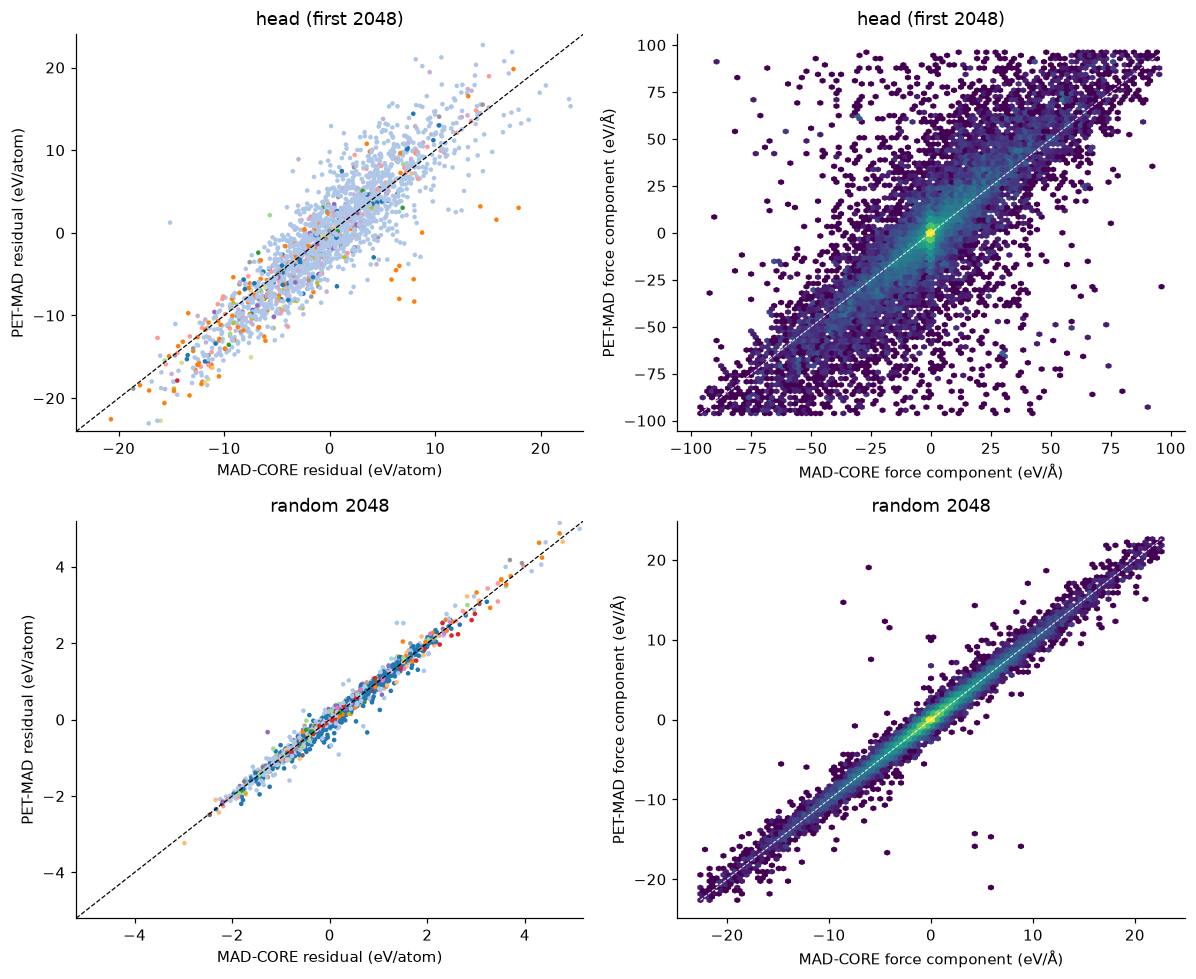

In [17]:
pet = PET_MAD.exists()
if pet:
    model = mta.load_atomistic_model(str(PET_MAD)).to(DEVICE)
    capabilities = model.capabilities()
    nc_name = mta.pick_output("non_conservative_force", capabilities.outputs)
    options = mta.ModelEvaluationOptions(
        length_unit="angstrom",
        outputs={"energy": mta.ModelOutput(sample_kind="system"), nc_name: mta.ModelOutput(sample_kind="atom")},
    )
    nl_calcs = vesin.metatomic.neighbor_lists_for_model("angstrom", model)
    dtype = getattr(torch, capabilities.dtype)

    def pet_mad(frames, batch_size=32):
        energies, forces = [], []
        for start in range(0, len(frames), batch_size):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                batch = mta.systems_to_torch(frames[start : start + batch_size])
            for c in nl_calcs:
                c.add_neighbor_list(batch)
            out = model([s.to(dtype=dtype, device=DEVICE) for s in batch], options, check_consistency=False)
            energies.append(out["energy"].block().values.detach().cpu().double().ravel())
            forces.append(out[nc_name].block().values.detach().cpu().double().reshape(-1, 3))
        return torch.cat(energies).numpy(), torch.cat(forces).numpy()

    calc = MetatomicCalculator(model, device=DEVICE)
    probe = [a.copy() for a in random_sample[:4]]
    assert np.allclose(pet_mad(probe)[0], [calc.compute_energy(a)["energy"] for a in probe], rtol=1e-4, atol=1e-3)

    def compare(frames, frame_df):
        known = set(capabilities.atomic_types)
        usable = [i for i, a in enumerate(frames) if set(a.numbers) <= known]
        frames = [frames[i] for i in usable]
        e, f = pet_mad(frames)
        rows = frame_df.fps_order.to_numpy()[usable]
        comp = X[rows][:, present].toarray().astype(float)
        residual = lambda en: (en - comp @ np.linalg.lstsq(comp, en, rcond=None)[0]) / comp.sum(1)  # noqa: E731
        ref_f = np.concatenate([a.arrays["ecumetric_nc_forces"] for a in frames])
        return {
            "structures": len(usable),
            "ref residual": residual(frame_df.ecumetric_energy.to_numpy()[usable]),
            "pet residual": residual(e),
            "ref forces": ref_f,
            "pet forces": f,
            "group": frame_df.group.to_numpy()[usable],
        }

    comparisons = {f"head (first {N_MAP})": compare(head, head_df), f"random {N_RANDOM}": compare(random_sample, random_df)}
    fig, ax = plt.subplots(2, 2, figsize=(11, 9))
    table = {}
    for row, (name, c) in zip(ax, comparisons.items()):
        a, b = c["ref residual"], c["pet residual"]
        lim = np.nanpercentile(np.abs(np.r_[a, b]), 99.5)
        row[0].scatter(a, b, s=4, c=[COLOR[g] for g in c["group"]])
        row[0].plot([-lim, lim], [-lim, lim], "k--", lw=0.8)
        row[0].set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel="MAD-CORE residual (eV/atom)", ylabel="PET-MAD residual (eV/atom)", title=name)
        flim = np.percentile(np.abs(c["ref forces"]), 99.5)
        row[1].hexbin(c["ref forces"].ravel(), c["pet forces"].ravel(), gridsize=100, bins="log", extent=(-flim, flim, -flim, flim))
        row[1].plot([-flim, flim], [-flim, flim], "w--", lw=0.6)
        row[1].set(xlabel="MAD-CORE force component (eV/Å)", ylabel="PET-MAD force component (eV/Å)", title=name)
        df_err = np.abs(c["ref forces"] - c["pet forces"])
        table[name] = {
            "structures": c["structures"],
            "energy residual MAE (eV/atom)": np.abs(a - b).mean(),
            "energy residual median AE (eV/atom)": np.median(np.abs(a - b)),
            "force MAE (eV/Å)": df_err.mean(),
            "force median AE (eV/Å)": np.median(df_err),
            "atoms with MAD-CORE |F| < 1e-4": np.mean(np.linalg.norm(c["ref forces"], axis=1) < 1e-4),
        }
    fig.tight_layout()
    display(pd.DataFrame(table).style.format("{:.3g}"))
else:
    print(f"no PET-MAD model at {PET_MAD}; set PET_MAD_MODEL to enable this section")

## 11. Interactive chemiscope view of the level-11 coreset

Properties are passed explicitly with descriptions and units rather than
dumped from `atoms.info`, forces are drawn as arrows, and the input is
written to `madcore-outputs/madcore-head.json.gz`, which opens on
<https://chemiscope.org> or with `chemiscope.show_input` without re-running
anything. (The record also ships `madcore_0-2pow20.chemiscope.json.gz`, a
view of the first $2^{20}$ structures.)

In [18]:
def prop(values, description, units=None):
    return {"target": "structure", "values": np.asarray(values).tolist(), "description": description, **({"units": units} if units else {})}


properties = {
    "fps_order": prop(head_df.fps_order, "rank in the coreset (0 = first pick)"),
    "dataset_group": prop(head_df.dataset_group.astype(str), "source dataset group"),
    "group": prop(head_df.group.astype(str), f"source group (top {TOP} of the whole coreset, rest = other)"),
    "n_atoms": prop(head_df.n_atoms, "number of atoms"),
    "periodic": prop(head_df.periodic.map({True: "periodic", False: "non-periodic"}), "periodic boundary conditions"),
    "energy per atom": prop(head_df.energy_per_atom, "ecumetric energy per atom", "eV"),
    "residual per atom": prop(head_df.residual_per_atom, "energy per atom minus composition baseline (fit on all rows)", "eV"),
    "max |F|": prop(head_df.max_force, "largest predicted force", "eV/Å"),
    "log10 epsilon_sq": prop(np.log10(head_df.epsilon_sq.clip(lower=1e-12)), "Hausdorff distance when picked"),
    "log10 voronoi population": prop(np.log10(head_df.voronoi_population.clip(lower=1)), "MAD-COSMO structures nearest to this pick"),
    "min distance": prop(head_df.min_distance.fillna(-1), "shortest interatomic distance (-1: single atom)", "Å"),
    **{f"feature PC{i + 1}": prop(pcs[:, i], f"selection features, PC{i + 1}") for i in range(3)},
}

shapes = {"forces": chemiscope.ase_vectors_to_arrows(head, "ecumetric_nc_forces", scale=0.3)}
settings = chemiscope.quick_settings(
    x="feature PC1",
    y="feature PC2",
    map_color="log10 epsilon_sq",
    symbol="group",
    structure_settings={"unitCell": True, "shape": "forces"},
)
metadata = {
    "name": f"MAD-CORE level-{int(np.log2(N_MAP))} coreset",
    "description": f"The first {N_MAP} of {n_rows:,} MAD-CORE structures in farthest-point-sampling order.",
    "authors": ["metawork notebooks/madcore-dataset-summary"],
}
chemiscope.write_input(str(OUT_DIR / "madcore-head.json.gz"), structures=head, properties=properties, shapes=shapes, settings=settings, metadata=metadata)
chemiscope.show(head, properties=properties, shapes=shapes, settings=settings, metadata=metadata)

<ChemiscopeWidget(meta={'name': 'MAD-CORE level-11 coreset', 'description': 'The first ...}, settings={'map': {'joinPoints': False, 'x': {'property': 'feature PC1'}, ...}, structures=[{'size': 1, 'data': 'structure-0'}, {'size': 6, 'data': 'struct...}, shapes={'forces': {'kind': 'arrow', 'parameters': {'global': {'baseRadi...}, properties={'fps_order': {'target': 'structure', 'values': [0.0, 1.0, 2.0, ...}, )>

## 12. Summary

In [19]:
summary = {
    "structures": f"{n_rows:,}",
    "atoms": f"{df.n_atoms.sum():,}",
    "elements": len(elements),
    "source datasets / groups present": f"{df.dataset_id.nunique()} / {df.dataset_group.nunique()}",
    "periodic": f"{df.periodic.mean():.1%}",
    "atoms per structure (median / mean / max)": f"{df.n_atoms.median():.0f} / {df.n_atoms.mean():.1f} / {df.n_atoms.max()}",
    "largest group": f"{overview.structures.idxmax()} ({overview.share_of_coreset.max():.1%})",
    "labels (model predictions, no DFT)": "ecumetric_energy, ecumetric_nc_forces",
    "composition-baseline residual, median |r| / MAE (eV/atom)": f"{df.residual_per_atom.abs().median():.3f} / {df.residual_per_atom.abs().mean():.3f}",
    "median max |F| (eV/Å)": f"{df.max_force.median():.2f}",
    "flagged outliers": f"{df.outlier.sum():,} ({df.outlier.mean():.3%})",
    "coreset resolution epsilon_sq, level 11 / last level": f"{levels.epsilon_sq.get(11, np.nan):.3g} / {levels.epsilon_sq.iloc[-1]:.3g}",
    "shortest distance in samples (Å)": f"{pd.concat([head_df, random_df]).min_distance.min():.2f}",
}
display(pd.Series(summary, name="MAD-CORE").to_frame())

,MAD-CORE
structures,"16,777,216"
atoms,"216,185,078"
elements,102
source datasets / groups present,666 / 336
periodic,95.6%
atoms per structure (median / mean / max),10 / 12.9 / 1000
largest group,OMat24 (56.3%)
"labels (model predictions, no DFT)","ecumetric_energy, ecumetric_nc_forces"
"composition-baseline residual, median |r| / MAE (eV/atom)",0.565 / 0.740
median max |F| (eV/Å),3.95
